- **Import dependencies**

In [82]:
%reset -f
import pandas as pd
import numpy as np
import pickle
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [ ]:
# Load the spline results
with open("/Users/euanbronsky/PyCharmMiscProject/4spline_results.pkl", "rb") as f:
    res_spline = pickle.load(f)


# ============================================================
# Extract spline objects
# ============================================================

at_pred_spline = res_spline["at_pred"]
basis_cols = res_spline["basis_cols"]

x_train_spline = res_spline["x_train_spline"]
x_test_spline = res_spline["x_test_spline"]
data_spline_full = res_spline["data_spline_full"]


# Prepare group function
def prepare_groups_spline(x):

    dates = np.sort(x["quote_date"].unique())

    y_groups = []
    Z_groups = []

    for date in dates:

        group = x[x["quote_date"] == date]

        y_groups.append(group["log_iv"].to_numpy(dtype=float))
        Z_groups.append(group[basis_cols].to_numpy(dtype=float))

    return dates, y_groups, Z_groups

# Predict the IV function
def predict_iv(Z_groups, at_pred):

    log_iv_pred = []

    for t in range(len(Z_groups)):

        Zt = Z_groups[t]
        beta_t = at_pred[:, t]

        log_iv_pred_t = Zt @ beta_t
        log_iv_pred.append(log_iv_pred_t)

    log_iv_pred = np.concatenate(log_iv_pred)
    iv_pred = np.exp(log_iv_pred)

    return log_iv_pred, iv_pred


# ============================================================
# Reconstruct training and testing dates from spline model
# ============================================================

dates_train_spline, y_groups_train_spline, Z_groups_train_spline = prepare_groups_spline(
    x_train_spline
)

dates_test_spline, y_groups_test_spline, Z_groups_test_spline = prepare_groups_spline(
    x_test_spline
)

n_train_dates_spline = len(dates_train_spline)


# ============================================================
# Use full non-bucketed data, split by same train/test dates
# ============================================================

x_train_spline_full_nn = data_spline_full[
    data_spline_full["quote_date"].isin(dates_train_spline)
].copy()

x_test_spline_full_nn = data_spline_full[
    data_spline_full["quote_date"].isin(dates_test_spline)
].copy()

x_train_spline_full_nn["quote_date"] = pd.Categorical(
    x_train_spline_full_nn["quote_date"],
    categories=dates_train_spline,
    ordered=True
)

x_test_spline_full_nn["quote_date"] = pd.Categorical(
    x_test_spline_full_nn["quote_date"],
    categories=dates_test_spline,
    ordered=True
)

x_train_spline_full_nn = x_train_spline_full_nn.sort_values("quote_date").copy()
x_test_spline_full_nn = x_test_spline_full_nn.sort_values("quote_date").copy()

x_train_spline_full_nn["quote_date"] = x_train_spline_full_nn["quote_date"].astype(str)
x_test_spline_full_nn["quote_date"] = x_test_spline_full_nn["quote_date"].astype(str)


# ============================================================
# Compute spline prior on full non-bucketed training data
# ============================================================

dates_train_full_spline_nn, y_groups_train_full_spline_nn, Z_groups_train_full_spline_nn = prepare_groups_spline(
    x_train_spline_full_nn
)

log_iv_prior_train_full_spline_nn, iv_prior_train_full_spline_nn = predict_iv(
    Z_groups_train_full_spline_nn,
    at_pred_spline[:, :len(dates_train_full_spline_nn)]
)


# ============================================================
# Compute spline prior on full non-bucketed testing data
# ============================================================

dates_test_full_spline_nn, y_groups_test_full_spline_nn, Z_groups_test_full_spline_nn = prepare_groups_spline(
    x_test_spline_full_nn
)

log_iv_prior_test_full_spline_nn, iv_prior_test_full_spline_nn = predict_iv(
    Z_groups_test_full_spline_nn,
    at_pred_spline[
        :,
        n_train_dates_spline:n_train_dates_spline + len(dates_test_full_spline_nn)
    ]
)


# ============================================================
# Create NN training dataframe from full non-bucketed training data
# ============================================================

x_train_nn = x_train_spline_full_nn.copy()

x_train_nn["iv_prior"] = iv_prior_train_full_spline_nn

iv_prior_floor = 0.02
x_train_nn["iv_prior_safe"] = x_train_nn["iv_prior"].clip(lower=iv_prior_floor)

x_train_nn["residual_target"] = (
    x_train_nn["iv_fun"] - x_train_nn["iv_prior"]
)

x_train_nn["abs_error_prior"] = np.abs(
    x_train_nn["residual_target"]
)


# ============================================================
# Clean training data
# ============================================================

x_train_nn = x_train_nn.replace([np.inf, -np.inf], np.nan)

x_train_nn = x_train_nn.dropna(
    subset=[
        "M",
        "T",
        "iv_fun",
        "iv_prior",
        "iv_prior_safe",
        "residual_target",
        "moneyness_group",
        "maturity_group"
    ]
).copy()


# ============================================================
# Train on all regions
# ============================================================

x_train_nn = x_train_nn.copy()


# ============================================================
# Features
# ============================================================

feature_cols = ["M", "T", "iv_prior_safe"]

print("Number of full non-bucketed training observations:", len(x_train_nn))
print("Average spline residual in full training sample:", x_train_nn["residual_target"].mean())
print("Spline prior MAE on full non-bucketed training sample:", x_train_nn["abs_error_prior"].mean())


# ============================================================
# Define neural network that predicts unrestricted positive
# total-variance multiplier
# ============================================================

class ResidualNN(nn.Module):

    def __init__(self, n_features):
        super().__init__()

        self.hidden = nn.Sequential(
            nn.Linear(n_features, 80),
            nn.Softplus(),

            nn.Linear(80, 80),
            nn.Softplus(),

            nn.Linear(80, 80),
            nn.Softplus()
        )

        self.output = nn.Linear(80, 1)

        self.initialize_weights()

    def initialize_weights(self):

        for layer in self.modules():

            if isinstance(layer, nn.Linear):

                fan_in = layer.weight.shape[1]
                fan_out = layer.weight.shape[0]

                std = (fan_in + fan_out) ** (-0.5)

                nn.init.normal_(layer.weight, mean=0.0, std=std)
                nn.init.normal_(layer.bias, mean=0.0, std=std)

        # Starts from no correction: exp(0) = 1
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, x):

        x = self.hidden(x)

        log_omega_multiplier = self.output(x)

        omega_multiplier = torch.exp(log_omega_multiplier)

        return omega_multiplier


# ============================================================
# Prepare NN training data
# ============================================================

X = x_train_nn[feature_cols].to_numpy(dtype=float)
y = x_train_nn[["iv_fun"]].to_numpy(dtype=float)
iv_prior = x_train_nn[["iv_prior_safe"]].to_numpy(dtype=float)
T = x_train_nn[["T"]].to_numpy(dtype=float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)
iv_prior_tensor = torch.tensor(iv_prior, dtype=torch.float32)
T_tensor = torch.tensor(T, dtype=torch.float32)

dataset = TensorDataset(
    X_tensor,
    y_tensor,
    iv_prior_tensor,
    T_tensor
)

loader = DataLoader(
    dataset,
    batch_size=65536,
    shuffle=True
)


# ============================================================
# Train neural network using RMSE + MAPE on final IV
# ============================================================

model = ResidualNN(n_features=len(feature_cols))

initial_lr = 0.001
current_lr = initial_lr

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=current_lr,
    weight_decay=1e-6
)

max_epochs = 400
lr_check_window = 100
stop_check_window = 200
required_improvement = 0.003

loss_history = []

for epoch in range(max_epochs):

    total_loss = 0.0

    for X_batch, y_batch, iv_prior_batch, T_batch in loader:

        optimizer.zero_grad()

        omega_multiplier = model(X_batch)

        omega_prior = iv_prior_batch ** 2 * T_batch
        omega_pred = omega_multiplier * omega_prior

        iv_pred = torch.sqrt(
            torch.clamp(
                omega_pred / torch.clamp(T_batch, min=1e-8),
                min=1e-12
            )
        )

        rmse = torch.sqrt(
            torch.mean((y_batch - iv_pred) ** 2)
        )

        mape = torch.mean(
            torch.abs(y_batch - iv_pred)
            / torch.clamp(y_batch, min=1e-8)
        )

        loss = rmse + mape

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    if epoch % 50 == 0:
        print(epoch, avg_loss, "lr:", current_lr)

    if epoch > 0 and epoch % lr_check_window == 0:

        old_loss = loss_history[epoch - lr_check_window]
        improvement = (old_loss - avg_loss) / old_loss

        if improvement < required_improvement:

            current_lr = current_lr / 2

            for param_group in optimizer.param_groups:
                param_group["lr"] = current_lr

            print("Reduced learning rate to", current_lr, "at epoch", epoch)

    if epoch > 0 and epoch % stop_check_window == 0:

        old_loss = loss_history[epoch - stop_check_window]
        improvement = (old_loss - avg_loss) / old_loss

        if improvement < required_improvement:
            print("Stopping: loss did not improve enough")
            break


# ============================================================
# Store fitted correction on full training sample
# ============================================================

model.eval()

with torch.no_grad():

    omega_multiplier_train = model(X_tensor).numpy().flatten()

x_train_nn["omega_multiplier_nn"] = omega_multiplier_train

omega_prior_train = (
    x_train_nn["iv_prior_safe"].to_numpy(dtype=float) ** 2
    * x_train_nn["T"].to_numpy(dtype=float)
)

omega_nn_train = (
    x_train_nn["omega_multiplier_nn"].to_numpy(dtype=float)
    * omega_prior_train
)

x_train_nn["iv_nn"] = np.sqrt(
    np.maximum(
        omega_nn_train
        / np.maximum(x_train_nn["T"].to_numpy(dtype=float), 1e-8),
        1e-12
    )
)

x_train_nn["iv_nn"] = x_train_nn["iv_nn"].clip(lower=1e-6)

x_train_nn["residual_nn"] = (
    x_train_nn["iv_nn"] - x_train_nn["iv_prior"]
)

x_train_nn["abs_error_nn"] = np.abs(
    x_train_nn["iv_fun"] - x_train_nn["iv_nn"]
)

print("NN corrected MAE on full non-bucketed training sample:", x_train_nn["abs_error_nn"].mean())
print("Average omega multiplier on full training sample:", x_train_nn["omega_multiplier_nn"].mean())
print("Minimum omega multiplier on full training sample:", x_train_nn["omega_multiplier_nn"].min())
print("Maximum omega multiplier on full training sample:", x_train_nn["omega_multiplier_nn"].max())


# ============================================================
# Evaluate on full non-bucketed testing data
# Correction is applied to all regions
# ============================================================

x_test_nn = x_test_spline_full_nn.copy()

x_test_nn["iv_prior"] = iv_prior_test_full_spline_nn

x_test_nn["iv_prior_safe"] = x_test_nn["iv_prior"].clip(lower=iv_prior_floor)

x_test_nn = x_test_nn.replace([np.inf, -np.inf], np.nan)

x_test_nn = x_test_nn.dropna(
    subset=[
        "M",
        "T",
        "iv_fun",
        "iv_prior",
        "iv_prior_safe",
        "moneyness_group",
        "maturity_group"
    ]
).copy()

# Correction applied to all regions
x_test_nn["residual_nn"] = 0.0
x_test_nn["omega_multiplier_nn"] = 1.0
x_test_nn["iv_nn"] = x_test_nn["iv_prior"]

correction_mask = np.ones(len(x_test_nn), dtype=bool)

X_test_region = x_test_nn.loc[
    correction_mask,
    feature_cols
].to_numpy(dtype=float)

X_test_region_scaled = scaler.transform(X_test_region)
X_test_region_tensor = torch.tensor(X_test_region_scaled, dtype=torch.float32)

model.eval()

with torch.no_grad():

    x_test_nn.loc[correction_mask, "omega_multiplier_nn"] = (
        model(X_test_region_tensor)
        .numpy()
        .flatten()
    )

omega_prior_test = (
    x_test_nn.loc[correction_mask, "iv_prior_safe"].to_numpy(dtype=float) ** 2
    * x_test_nn.loc[correction_mask, "T"].to_numpy(dtype=float)
)

omega_nn_test = (
    x_test_nn.loc[correction_mask, "omega_multiplier_nn"].to_numpy(dtype=float)
    * omega_prior_test
)

x_test_nn.loc[correction_mask, "iv_nn"] = np.sqrt(
    np.maximum(
        omega_nn_test
        / np.maximum(x_test_nn.loc[correction_mask, "T"].to_numpy(dtype=float), 1e-8),
        1e-12
    )
)

x_test_nn["iv_nn"] = x_test_nn["iv_nn"].clip(lower=1e-6)

x_test_nn["residual_nn"] = (
    x_test_nn["iv_nn"] - x_test_nn["iv_prior"]
)

x_test_nn["abs_error_prior"] = np.abs(
    x_test_nn["iv_fun"] - x_test_nn["iv_prior"]
)

x_test_nn["abs_error_nn"] = np.abs(
    x_test_nn["iv_fun"] - x_test_nn["iv_nn"]
)

print("Spline prior MAE on full non-bucketed testing data:", x_test_nn["abs_error_prior"].mean())
print("NN total-variance multiplicative-corrected MAE on full non-bucketed testing data, all regions:", x_test_nn["abs_error_nn"].mean())

print("Average predicted residual by moneyness group:")
print(x_test_nn.groupby("moneyness_group")["residual_nn"].mean())

print("Average predicted omega multiplier by moneyness group:")
print(x_test_nn.groupby("moneyness_group")["omega_multiplier_nn"].mean())

print("OOS MAE by moneyness group:")
print(
    x_test_nn
    .groupby("moneyness_group")[["abs_error_prior", "abs_error_nn"]]
    .mean()
)

print("OOS MAE by maturity group:")
print(
    x_test_nn
    .groupby("maturity_group")[["abs_error_prior", "abs_error_nn"]]
    .mean()
)

Number of full non-bucketed training observations: 2244370
Average spline residual in full training sample: 0.02081727595067147
Spline prior MAE on full non-bucketed training sample: 0.02782651142645279
0 0.17736958350454057 lr: 0.001
50 0.05880278700164386 lr: 0.001
100 0.05841488753046308 lr: 0.001


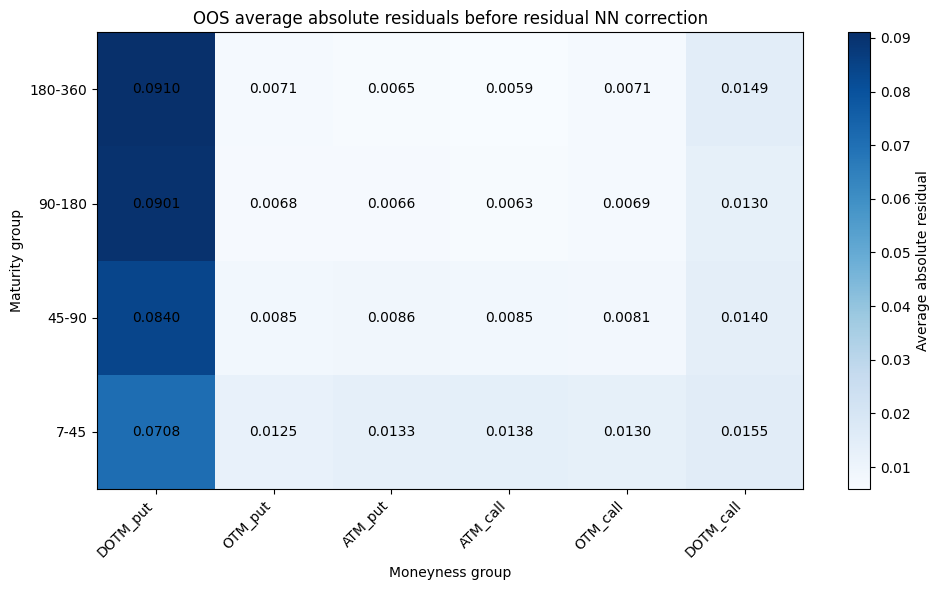

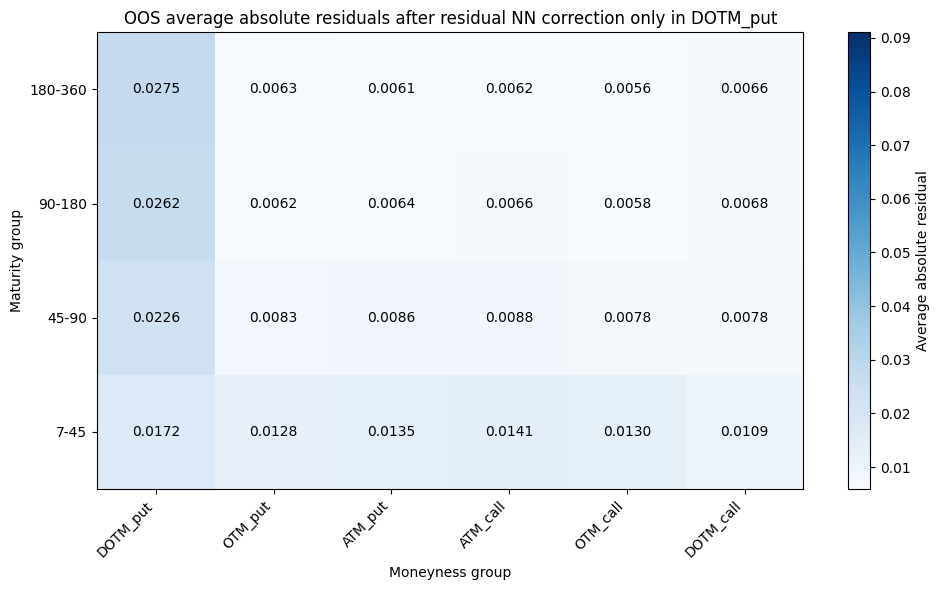

moneyness_group,DOTM_put,OTM_put,ATM_put,ATM_call,OTM_call,DOTM_call
maturity_group,,,,,,
7-45,0.017217,0.012784,0.013535,0.014078,0.012968,0.010919
45-90,0.022562,0.008299,0.008643,0.008768,0.007760,0.007763
90-180,0.026200,0.006245,0.006364,0.006591,0.005774,0.006848
180-360,0.027455,0.006289,0.006116,0.006191,0.005607,0.006637


In [58]:
def make_oos_nn_heatmap(
    data_heatmap,
    value_col,
    title,
    ax=None,
    show=True,
    vmin=None,
    vmax=None
):

    maturity_order = ["7-45", "45-90", "90-180", "180-360"]
    moneyness_order = ["DOTM_put", "OTM_put", "ATM_put", "ATM_call", "OTM_call", "DOTM_call"]

    data_heatmap = data_heatmap.copy()

    data_heatmap["maturity_group"] = pd.Categorical(
        data_heatmap["maturity_group"],
        categories=maturity_order,
        ordered=True
    )

    data_heatmap["moneyness_group"] = pd.Categorical(
        data_heatmap["moneyness_group"],
        categories=moneyness_order,
        ordered=True
    )

    heatmap_table = data_heatmap.pivot_table(
        values=value_col,
        index="maturity_group",
        columns="moneyness_group",
        aggfunc="mean",
        observed=False
    ).reindex(index=maturity_order, columns=moneyness_order)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure

    im = ax.imshow(
        heatmap_table,
        aspect="auto",
        cmap="Blues",
        vmin=vmin,
        vmax=vmax
    )

    for i in range(heatmap_table.shape[0]):

        for j in range(heatmap_table.shape[1]):

            value = heatmap_table.iloc[i, j]

            if pd.notna(value):
                label = f"{value:.4f}"
            else:
                label = ""

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center"
            )

    ax.invert_yaxis()

    ax.set_xticks(range(len(moneyness_order)))
    ax.set_xticklabels(moneyness_order, rotation=45, ha="right")

    ax.set_yticks(range(len(maturity_order)))
    ax.set_yticklabels(maturity_order)

    ax.set_xlabel("Moneyness group")
    ax.set_ylabel("Maturity group")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Average absolute residual")

    if show:
        fig.tight_layout()
        plt.show()

    return heatmap_table


heatmap_oos_prior = make_oos_nn_heatmap(
    x_test_nn,
    value_col="abs_error_prior",
    title="OOS average absolute residuals before residual NN correction"
)

vmin_common = heatmap_oos_prior.min().min()
vmax_common = heatmap_oos_prior.max().max()

heatmap_oos_nn_dotm_only = make_oos_nn_heatmap(
    x_test_nn,
    value_col="abs_error_nn",
    title="OOS average absolute residuals after residual NN correction only in DOTM_put",
    vmin=vmin_common,
    vmax=vmax_common
)

heatmap_oos_nn_dotm_only

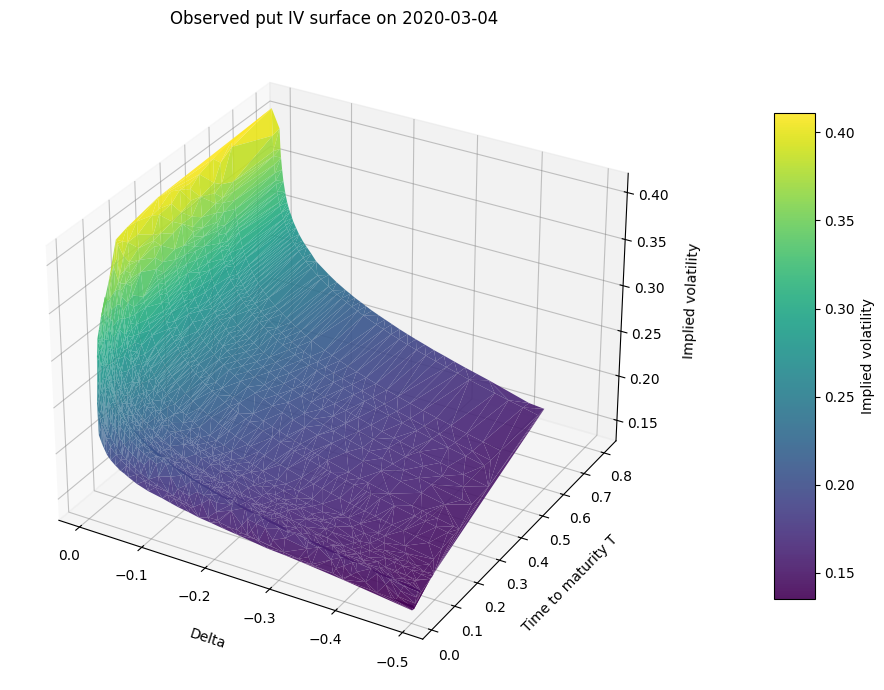

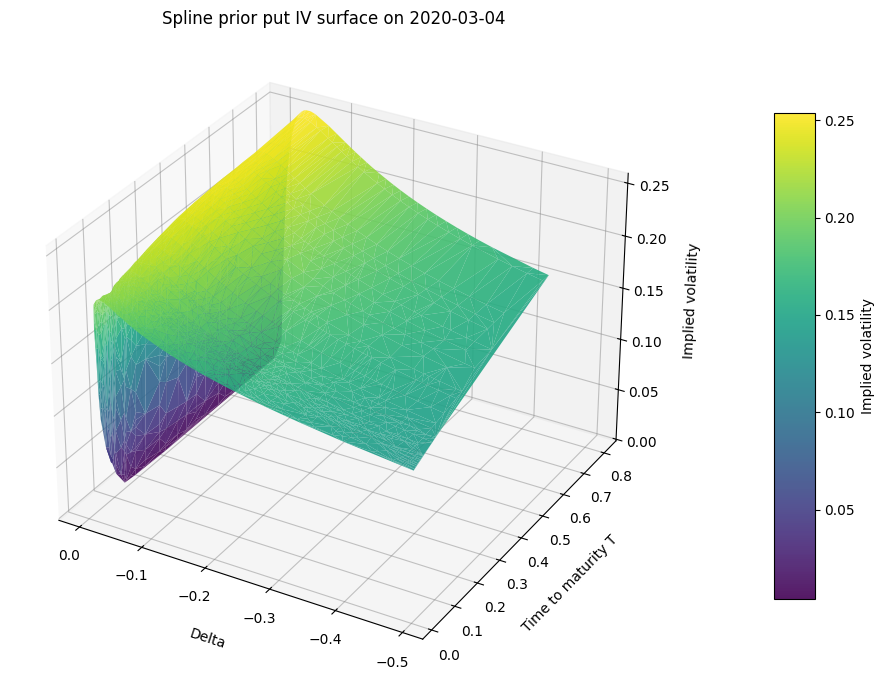

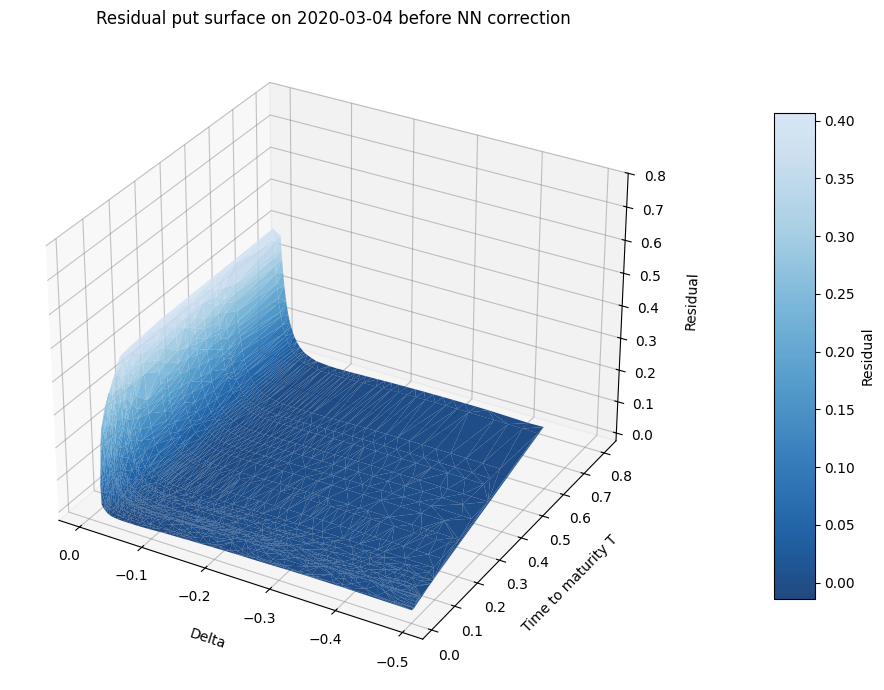

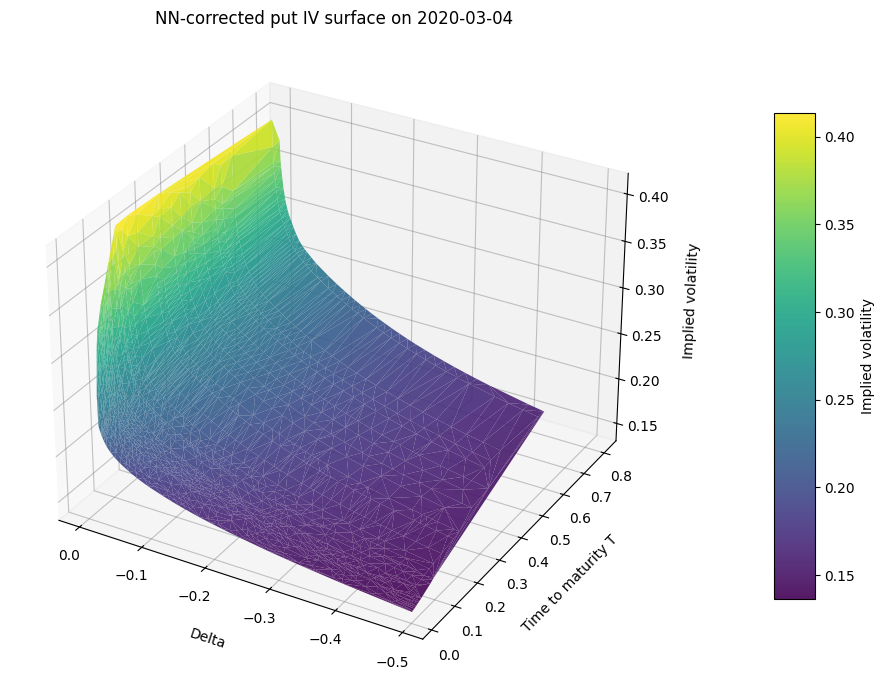

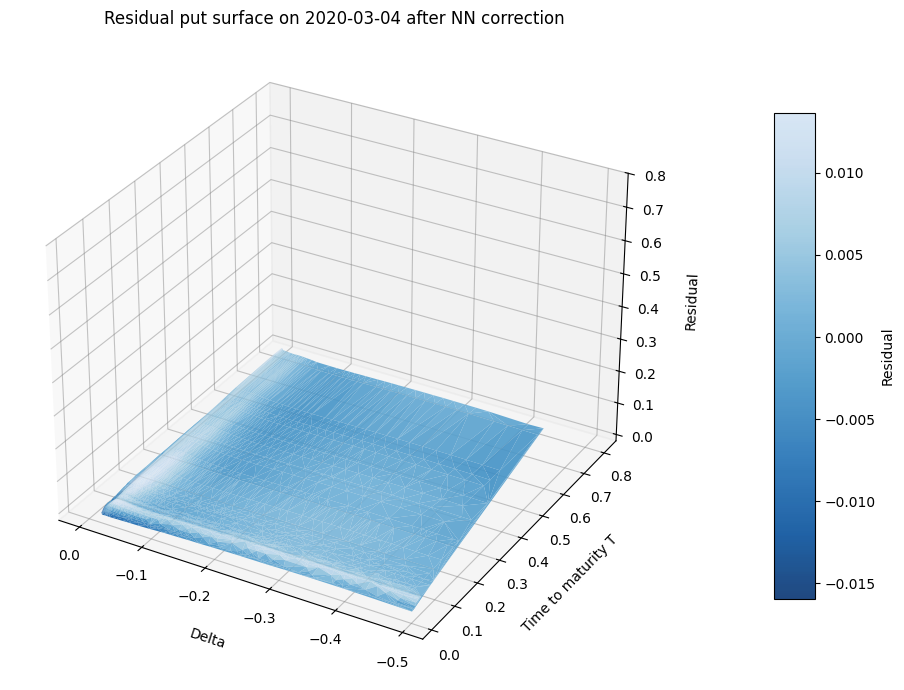

In [72]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm

plot_date = pd.Timestamp("2019-06-12").date()

surface_date = x_test_nn[
    pd.to_datetime(x_test_nn["quote_date"]).dt.date.eq(plot_date)
].copy()

surface_date = surface_date[
    surface_date["moneyness_group"].isin(["DOTM_put", "OTM_put", "ATM_put"])
].copy()

surface_date["residual_prior"] = (
    surface_date["iv_fun"] - surface_date["iv_prior"]
)

surface_date["residual_nn_corrected"] = (
    surface_date["iv_fun"] - surface_date["iv_nn"]
)

blues_no_white = LinearSegmentedColormap.from_list(
    "blues_no_white",
    cm.Blues_r(np.linspace(0.02, 0.82, 256))
)


def plot_trisurf_surface(
    data,
    value_col,
    title,
    zlabel,
    zmin=None,
    zmax=None,
    cmap="viridis"
):
    plot_data = (
        data[["delta_fun", "T", value_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    x = plot_data["delta_fun"].to_numpy(dtype=float)
    y = plot_data["T"].to_numpy(dtype=float)
    z = plot_data[value_col].to_numpy(dtype=float)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_trisurf(
        x,
        y,
        z,
        cmap=cmap,
        edgecolor="none",
        antialiased=True,
        alpha=0.9
    )

    ax.set_xlabel("Delta", labelpad=10)
    ax.set_ylabel("Time to maturity T", labelpad=10)
    ax.set_zlabel(zlabel, labelpad=10)
    ax.invert_xaxis()
    ax.set_title(title)

    #ax.view_init(elev=20, azim=-25)

    ax.xaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.yaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.zaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)

    if zmin is not None or zmax is not None:
        ax.set_zlim(bottom=zmin, top=zmax)

    cbar = fig.colorbar(
        surf,
        ax=ax,
        shrink=0.75,
        aspect=12,
        pad=0.12
    )
    cbar.set_label(zlabel)

    plt.tight_layout()
    plt.show()


plot_trisurf_surface(
    surface_date,
    "iv_fun",
    "Observed put IV surface on 2020-03-04",
    "Implied volatility"
)

plot_trisurf_surface(
    surface_date,
    "iv_prior",
    "Spline prior put IV surface on 2020-03-04",
    "Implied volatility"
)

plot_trisurf_surface(
    surface_date,
    "residual_prior",
    "Residual put surface on 2020-03-04 before NN correction",
    "Residual",
    zmax=0.8,
    cmap=blues_no_white
)

plot_trisurf_surface(
    surface_date,
    "iv_nn",
    "NN-corrected put IV surface on 2020-03-04",
    "Implied volatility"
)

plot_trisurf_surface(
    surface_date,
    "residual_nn_corrected",
    "Residual put surface on 2020-03-04 after NN correction",
    "Residual",
    zmax=0.8,
    cmap=blues_no_white
)

# **No-arbitrage**
---------------------------------

In [ ]:
# Penalty function
def penalty_formulas(M, omega, omega_M, omega_T, omega_MM, eps=1e-8):

    # Clip omega for stability
    omega_safe = torch.clamp(omega, min=eps)

    # Calendary penalty
    calendar_penalty = torch.mean(
        torch.relu(-omega_T))

    # Butterfly condition
    butterfly_condition = (
        (1.0 - M * omega_M / (2.0 * omega_safe)) ** 2
        - (omega_M / 4.0) * (1.0 / omega_safe + 0.25)
        + 0.5 * omega_MM)

    # Butterfly penalty
    butterfly_penalty = torch.mean(
        torch.relu(-butterfly_condition))

    # Asymptotic penalty
    asymptotic_penalty = torch.mean(
        torch.abs(omega_MM))

    # Return the penalties
    return calendar_penalty, butterfly_penalty, asymptotic_penalty